<a href="https://colab.research.google.com/github/anug1/ECS260_data_gathering_processing/blob/main/Lime_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install lime xgboost scikit-learn

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd
import pickle
from lime.lime_tabular import LimeTabularExplainer


In [21]:
df = pd.read_csv("/content/drive/MyDrive/CRM/final_dataset_with_y.csv")

print(df.shape)
df.head()


(48686, 41)


,repo_name,is_fork,fork_owner_type,created_at,total_commits,commit_frequency_per_week,unique_commit_authors,issues_opened,issues_closed,issue_close_rate,...,parent_stars,parent_forks,parent_created_at,parent_language,early_commits_on_branch,parent_early_commits,divergence_ratio,primary_language,topics,is_sustainable
0,eowyncim/snarkOS,True,User,2023-12-04 17:02:26+00:00,0,0.000000,0,0,0,NaN,...,4509.0,2682.0,2020-02-16T21:46:21Z,Rust,0.0,1093.0,0.0,Rust,NaN,0
1,sumitpatro143/minimal,True,User,2024-01-03 00:57:14+00:00,1,0.038462,1,0,0,NaN,...,1780.0,6394.0,2016-10-06T23:07:49Z,SCSS,5.0,5.0,0.5,SCSS,NaN,0
2,olduma/layout_product-cards,True,User,2024-01-31 07:35:47+00:00,1,0.038462,1,0,0,NaN,...,20.0,5417.0,2019-04-24T12:05:45Z,JavaScript,0.0,13.0,0.0,JavaScript,NaN,0
3,crucial-keydev/Spoon-Knife,True,User,2024-01-23 20:40:25+00:00,0,0.000000,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,nanimonii/hello-uniapp,True,User,2023-12-11 07:54:24+00:00,0,0.000000,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [22]:
y = df['is_sustainable']

X = df.drop(columns=[
    'is_sustainable',
    'repo_name',
    'created_at',
    'parent_created_at',
    'topics',
    'parent_repo'
])
print(X.shape)



(48686, 35)


In [23]:
numerical_cols = X.select_dtypes(include=['number']).columns
categorical_cols = X.select_dtypes(include=['object','bool']).columns


In [24]:

# keep top 10, group rest
for col in X.filter(like="primary_language_").columns:
    if col not in top_languages:
        X.drop(columns=col, inplace=True)


for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mode()[0])


for col in X.select_dtypes(include=['bool']).columns:
    X[col] = X[col].astype(int)



/tmp/ipykernel_2379/983519490.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


In [25]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(X.shape)


(48686, 502)


In [26]:
language_cols = X.filter(regex="primary_language_|parent_language_").columns

top_languages = X[language_cols].sum().sort_values(ascending=False).head(10).index

X = X.drop(columns=[col for col in language_cols if col not in top_languages])

print("Shape after language reduction:", X.shape)


Shape after language reduction: (48686, 42)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(38948, 42) (9738, 42)


In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, recall_score, roc_auc_score, precision_score
from xgboost import XGBClassifier
from IPython.display import display


# Train model (same as before)
class_counts = y_train.value_counts()
neg_count = class_counts[0]
pos_count = class_counts[1]

scale_pos_weight = neg_count / pos_count

xgb_model_balanced = XGBClassifier(
    random_state=42,
    eval_metric=['logloss','auc','error'],
    scale_pos_weight=scale_pos_weight
)

xgb_model_balanced.fit(X_train, y_train)

# Get probabilities once
y_scores = xgb_model_balanced.predict_proba(X_test)[:, 1]

# AUC stays constant
auc = roc_auc_score(y_test, y_scores)

# Define thresholds (your "k")
thresholds = [0.3, 0.5, 0.7]

results = []

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)

    results.append({
        "k": round(t, 2),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print("AUC:", round(auc, 4))
display(results_df)


AUC: 0.8626


,k,Precision,F1,Recall
0,0.3,0.197115,0.296564,0.598540
1,0.5,0.248299,0.338747,0.532847
2,0.7,0.269036,0.317365,0.386861


In [28]:
X_sample = X.sample(1000, random_state=42)

explainer = LimeTabularExplainer(
    training_data=X_sample.values,
    feature_names=X.columns.tolist(),
    class_names=["Not Sustainable","Sustainable"],
    mode="classification"
)

print("LIME explainer ready.")


LIME explainer ready.


In [29]:
import numpy as np
from collections import defaultdict
import re

# --- Robust feature cleaner (FIXES "19.00" BUG) ---
def clean_feature(feature):
    parts = re.split(r'<=|>=|<|>|=', feature)
    for p in parts:
        p = p.strip()
        # return the part that is NOT just a number
        if not re.match(r'^[-+]?\d+(\.\d+)?$', p): # Added '+' to handle negative numbers
            return p
    return feature # fallback

importance_sum = defaultdict(float)
abs_importance_sum = defaultdict(float)
count = defaultdict(int)
pos_count = defaultdict(int)

np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 100, replace=False)

for i in sample_indices:

    exp = explainer.explain_instance(
        X_test.values[i],
        xgb_model_balanced.predict_proba,
        num_features=20,
        num_samples=1000
    )

    weights = np.array([abs(w) for _, w in exp.as_list()])
    total = weights.sum()

    for feature, weight in exp.as_list():
        feature_name = clean_feature(feature)

        norm_weight = weight / total if total > 0 else 0

        importance_sum[feature_name] += norm_weight
        abs_importance_sum[feature_name] += abs(norm_weight)
        count[feature_name] += 1
        if weight > 0:
            pos_count[feature_name] += 1

In [30]:
import pandas as pd

# --- Final aggregation (as per user's example) ---
results = {}
for f in importance_sum:
    if count[f] > 0: # Ensure no division by zero
        results[f] = {
            "mean_signed": importance_sum[f] / count[f],
            "mean_abs": abs_importance_sum[f] / count[f],
            "pos_ratio": pos_count[f] / count[f],
            "count": count[f]
        }
    else:
        results[f] = {
            "mean_signed": 0.0,
            "mean_abs": 0.0,
            "pos_ratio": 0.0,
            "count": 0
        }

# --- Convert to DataFrame (user's lime_df) ---
lime_df = pd.DataFrame.from_dict(results, orient='index')
lime_df = lime_df.reset_index().rename(columns={'index': 'Feature'})
lime_df = lime_df.sort_values(by="mean_abs", ascending=False)

# Preserve fork_lime_df, avg_abs, and avg_signed for downstream compatibility
fork_lime_df = lime_df.rename(columns={
    'mean_signed': 'Avg_Signed_Importance',
    'mean_abs': 'Avg_Absolute_Importance'
})[['Feature', 'Avg_Signed_Importance', 'Avg_Absolute_Importance']]

avg_abs = lime_df.set_index('Feature')['mean_abs'].to_dict()
avg_signed = lime_df.set_index('Feature')['mean_signed'].to_dict()

print("Aggregated LIME Importance (top 20 features):")
display(lime_df.head(20))

Aggregated LIME Importance (top 20 features):


,Feature,mean_signed,mean_abs,pos_ratio,count
0,early_commits_on_branch,-0.094032,0.165350,0.210000,100
1,prs_rejected,0.005671,0.058226,0.642857,70
20,issues_opened,0.006961,0.056000,0.701493,67
7,has_cicd_1,-0.028230,0.055505,0.255102,98
2,total_issue_comments,0.028427,0.054530,0.845070,71
9,pr_acceptance_rate,0.021408,0.054393,0.762500,80
3,parent_language_Java,-0.043687,0.050416,0.092105,76
5,fork_count,0.015895,0.049880,0.776119,67
14,parent_stars,0.021186,0.047895,0.742857,70
16,num_releases,0.026726,0.047241,0.833333,72


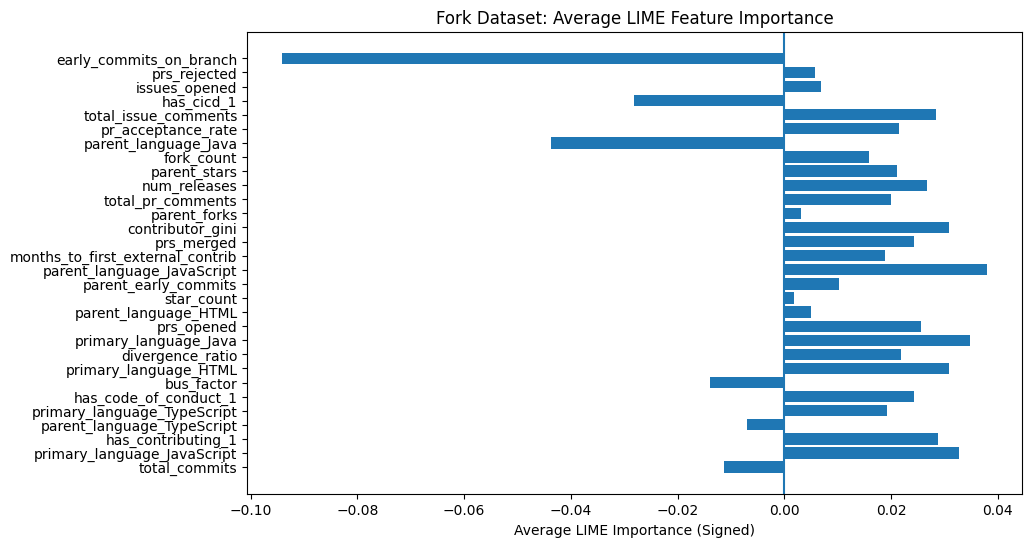

In [31]:
import matplotlib.pyplot as plt

top_features = fork_lime_df.sort_values(
    by="Avg_Absolute_Importance",
    ascending=False
).head(30)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Avg_Signed_Importance"]
)

plt.axvline(0)  # zero line for positive/negative split
plt.xlabel("Average LIME Importance (Signed)")
plt.title("Fork Dataset: Average LIME Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [23]:
abs_importance = {
    f: abs(v) for f, v in avg_abs.items()
}

# Convert to DataFrame for easier viewing
abs_importance_df = pd.DataFrame(
    sorted(abs_importance.items(), key=lambda x: x[1], reverse=True),
    columns=["Feature", "Absolute_Importance"]
)

print("Absolute LIME Importance from avg_abs:")
display(abs_importance_df.head())

Absolute LIME Importance from avg_abs:


,Feature,Absolute_Importance
0,parent_language_DM,0.408816
1,early_commits_on_branch,0.150490
2,parent_language_Astro,0.115872
3,total_pr_comments,0.108000
4,parent_language_GLSL,0.106724
